In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import  make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

### Загрузим подготовленные данные из ноутбука data.ipynb

In [23]:
df = pd.read_csv('prepared_data.csv')
df

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,FCVC,CAEC,CH2O,FAF,TUE,CALC,Age,Height,Weight,NCP,NObeyesdad
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,0,1,0,21.000000,1.620000,64.000000,3.0,Normal_Weight
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2,1,2,3,0,1,21.000000,1.520000,56.000000,3.0,Normal_Weight
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,2,1,2,23.000000,1.800000,77.000000,3.0,Normal_Weight
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,1,1,2,0,2,27.000000,1.800000,87.000000,3.0,Overweight_Level_I
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1,1,0,0,1,22.000000,1.780000,89.800000,1.0,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,2,1,1,20.976842,1.710730,131.408528,3.0,Obesity_Type_III
2107,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,1,1,1,21.982942,1.748584,133.742943,3.0,Obesity_Type_III
2108,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,1,1,1,22.524036,1.752206,133.689352,3.0,Obesity_Type_III
2109,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,2,1,1,1,24.361936,1.739450,133.346641,3.0,Obesity_Type_III


In [14]:
x = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y)

### Строим базовую модель SVM со стратификацией

In [15]:
def make_model(pipeline, x, y):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred_cv_full = cross_val_predict(estimator=pipeline, 
                                   X=x, 
                                   y=y, 
                                   cv=stratified_kfold, 
                                   n_jobs=-1)

    print("Classification Report - Full Model CV:")
    print(classification_report(y_train, y_pred_cv_full, target_names=y.unique()))

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_train, y_pred_cv_full), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Full Model CV')
    plt.show()

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.91      1.00      0.95       204
 Overweight_Level_I       0.96      0.84      0.89       215
Insufficient_Weight       0.99      0.96      0.97       263
     Obesity_Type_I       0.97      0.99      0.98       223
    Obesity_Type_II       1.00      1.00      1.00       243
      Normal_Weight       0.87      0.92      0.89       217
   Obesity_Type_III       0.93      0.93      0.93       218

           accuracy                           0.95      1583
          macro avg       0.95      0.95      0.95      1583
       weighted avg       0.95      0.95      0.95      1583



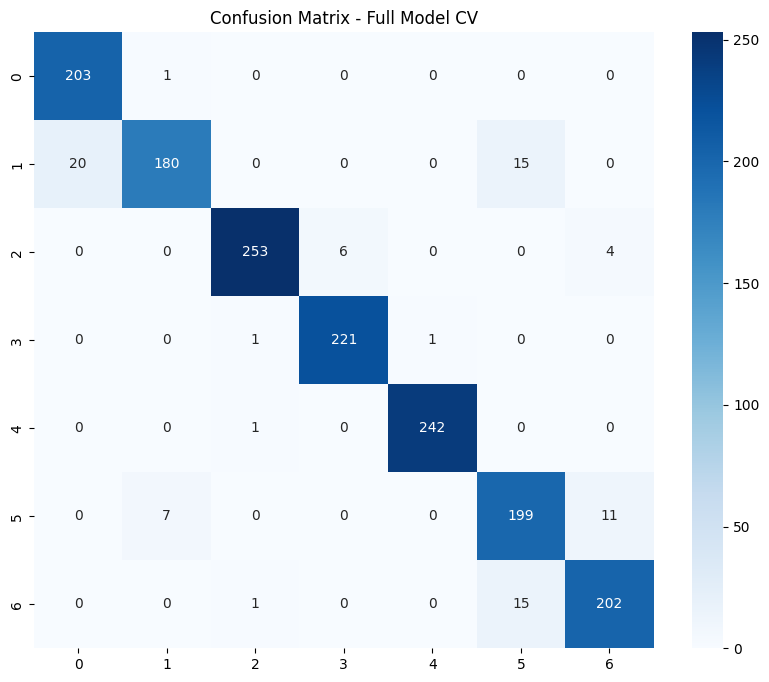

In [16]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42)
    )
make_model(pipeline, X_train, y_train)

### Использование масштабирования параметров сильно повышает точность предсказания модели! Попробуем использовать ядро RBF для модели SVM, а также введем параметр регуляризации и коэффициент для ядра

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.87      0.88      0.87       204
 Overweight_Level_I       0.66      0.74      0.70       215
Insufficient_Weight       0.89      0.85      0.87       263
     Obesity_Type_I       0.93      0.98      0.95       223
    Obesity_Type_II       1.00      0.99      1.00       243
      Normal_Weight       0.76      0.69      0.72       217
   Obesity_Type_III       0.79      0.75      0.77       218

           accuracy                           0.84      1583
          macro avg       0.84      0.84      0.84      1583
       weighted avg       0.84      0.84      0.84      1583



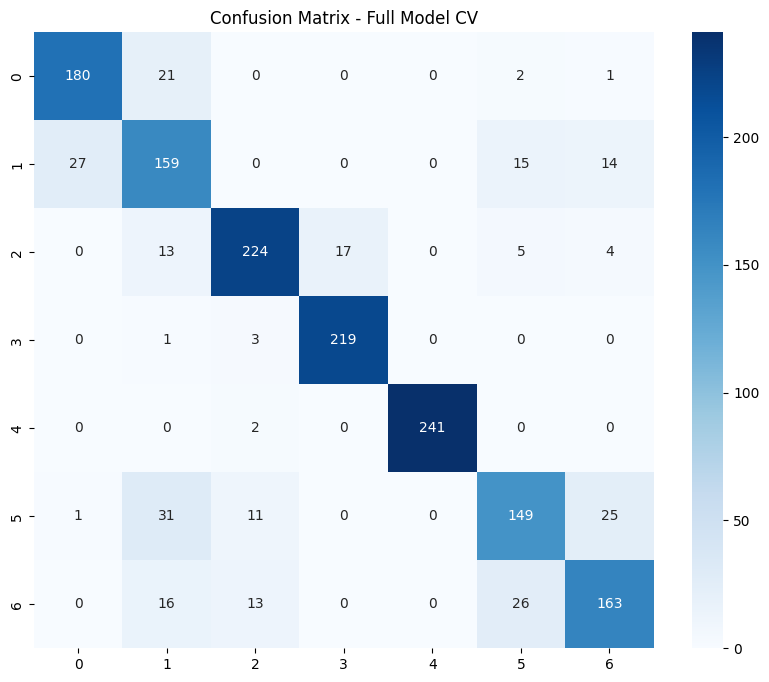

In [17]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    )
make_model(pipeline, X_train, y_train)

### Видим, что для таких параметров модель хуже работает, чем для линейного ядра. Попробуем запустить модель с полиномильным ядром и сигмоидным, и дальше используем поиск гиперпараметров

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.89      0.95      0.91       204
 Overweight_Level_I       0.81      0.76      0.78       215
Insufficient_Weight       0.96      0.95      0.96       263
     Obesity_Type_I       0.99      0.99      0.99       223
    Obesity_Type_II       1.00      1.00      1.00       243
      Normal_Weight       0.85      0.80      0.83       217
   Obesity_Type_III       0.85      0.89      0.87       218

           accuracy                           0.91      1583
          macro avg       0.91      0.91      0.91      1583
       weighted avg       0.91      0.91      0.91      1583



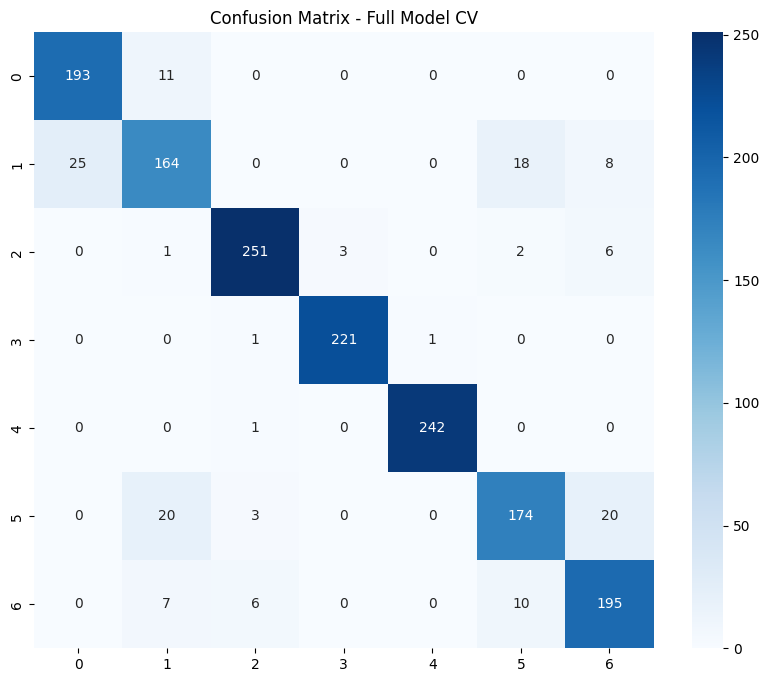

In [18]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='poly', degree=3, gamma='scale', coef0=1.0, random_state=42)
    )
make_model(pipeline, X_train, y_train)

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.53      0.50      0.51       204
 Overweight_Level_I       0.37      0.41      0.39       215
Insufficient_Weight       0.74      0.73      0.74       263
     Obesity_Type_I       0.85      0.91      0.88       223
    Obesity_Type_II       0.99      1.00      0.99       243
      Normal_Weight       0.58      0.58      0.58       217
   Obesity_Type_III       0.52      0.46      0.49       218

           accuracy                           0.67      1583
          macro avg       0.65      0.66      0.65      1583
       weighted avg       0.66      0.67      0.66      1583



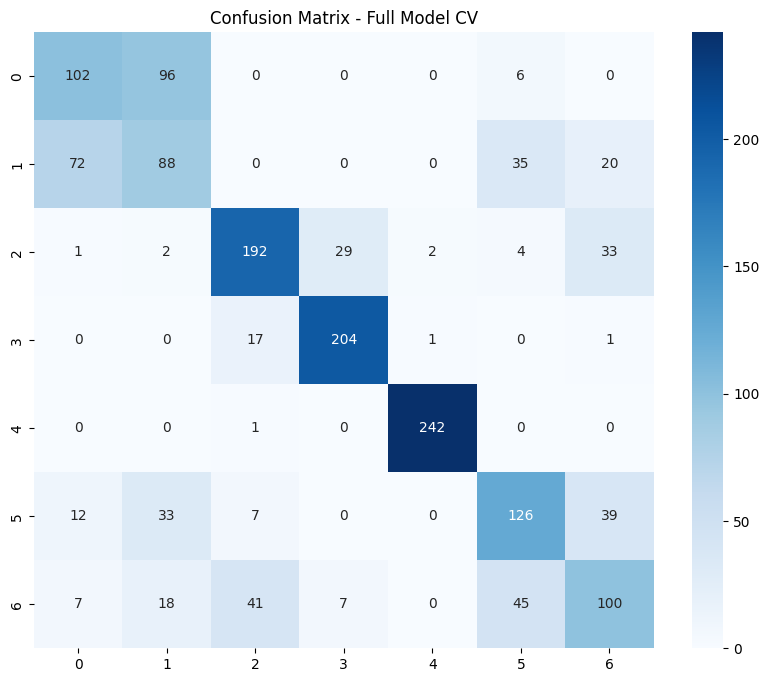

In [19]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='sigmoid', gamma='scale', coef0=0.0, C=1.0, random_state=42)
    )
make_model(pipeline, X_train, y_train)

In [20]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(random_state=42)
    )

param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'svc__class_weight': [None, 'balanced']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
        'svc__class_weight': [None, 'balanced']
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'svc__degree': [2, 3, 4, 5],
        'svc__gamma': ['scale', 'auto', 0.1, 1],
        'svc__coef0': [0.0, 0.5, 1.0, 2.0],
        'svc__class_weight': [None, 'balanced']
    },
    {
        'svc__kernel': ['sigmoid'],
        'svc__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svc__coef0': [0.0, 0.1, 0.5, 1.0]
    }
]

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'svc__C': 10, 'svc__class_weight': None, 'svc__kernel': 'linear'}
Лучшая точность: 0.967211604954545


Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Overweight_Level_II       0.96      0.99      0.98       204
 Overweight_Level_I       0.98      0.94      0.96       215
Insufficient_Weight       0.98      0.97      0.98       263
     Obesity_Type_I       0.99      0.98      0.99       223
    Obesity_Type_II       1.00      1.00      1.00       243
      Normal_Weight       0.92      0.94      0.93       217
   Obesity_Type_III       0.93      0.94      0.93       218

           accuracy                           0.97      1583
          macro avg       0.97      0.97      0.97      1583
       weighted avg       0.97      0.97      0.97      1583



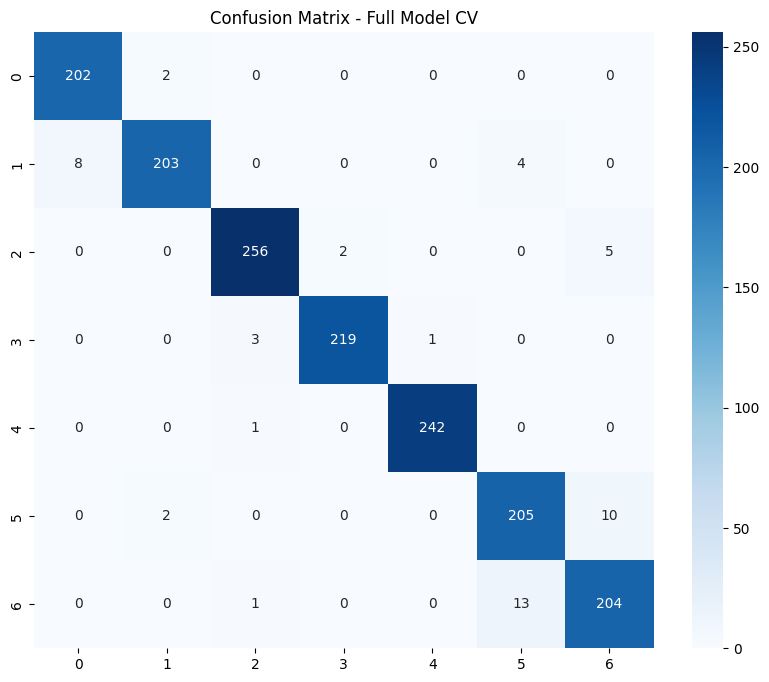

In [21]:
pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', C=10.0, random_state=42)
    )
make_model(pipeline, X_train, y_train)

In [22]:
#RandomizedSearchCV, 